# Causal forest - mRS 0-4

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import statsmodels.api as sm

from econml.dml import CausalForestDML # Causal forest with double machine learning
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier 

## Define mRS outcome target and cutoff for early treatment

In [2]:
MRS_TARGET = 4 # Model will set y as being less than or equal to this value

CUTOFF = 270

## Define adjustment fields

In [3]:
NON_CATEGORICAL_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'year',
    'onset_to_scan_time'
]

CATEGORICAL_FEATURES = [
    'stroke_team',
    'ethnicity',
    'treatment_group'
]

"""
X is the set of variables you want the treatment effect to depend on. # The causal forest builds 
trees that split on X, grouping patients so that the treatment effect is roughly constant within
a leaf.

W is the set of variables you want to control for. The causal forest will adjust for these 
variables, but will not split on them.

A feature belongs in X if you think the treatment effect may vary with it, and in W if it's a
confounder you need to adjust away. Many variables are both a confounder and an effect modifier, 
so they legitimately belong in both groups.
"""


X_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
]

W_FEATURES = [
    'prior_disability',
    'stroke_severity',
    'age',
    'congestive_heart_failure',
    'hypertension',
    'diabetes',
    'afib_anticoagulant',
    'any_afib_diagnosis',
    'ethnicity',
    'stroke_team',
    'year',
    'onset_to_scan_time'
]

TREATMENTS = [
    'onset_to_thrombolysis_time',
    'onset_to_thrombectomy_time',
]

# Combine the X and W treatment features into a single list of features
cf_features = list(set(X_FEATURES + W_FEATURES + TREATMENTS))
descriptive_features = list(set(NON_CATEGORICAL_FEATURES + CATEGORICAL_FEATURES))

## Load and filter data

In [4]:
data = pd.read_csv("../../data/sam3/cleaned_data.csv", low_memory=False)

# Calculate onset_to_scan
data["onset_to_scan_time"] = data["onset_to_arrival_time"] - data["arrival_to_scan_time"]

print(f"Initial data shape: {data.shape}")

# Remove rows with missing discharge disability
data = data.dropna(subset=["discharge_disability"])

# Keep only infarction cases
data = data[data["infarction"] == 1]

# Keep only onset to arrival < 360 mins
data = data[data["onset_to_arrival_time"] < 360]

# Keep only perfusion_imaging_used == 0
data = data[data["perfusion_imaging_used"] == 0]

# Limit to stroke severity  > 5 
data = data[((data["stroke_severity"] > 5) | data["lvo"] == 1)]

# Keep only teams with at least 10 onset_to_thrombectomy_time
team_counts = data.groupby("stroke_team")["onset_to_thrombectomy_time"].count()
valid_teams = team_counts[team_counts >= 10].index
data = data[data["stroke_team"].isin(valid_teams)]

# Missing treatment times -> sentinel
data["onset_to_thrombolysis_time"] = data["onset_to_thrombolysis_time"].fillna(99999)
data["onset_to_thrombectomy_time"] = data["onset_to_thrombectomy_time"].fillna(99999)

# Remove rows where thrombolysis is after thrombectomy (if both are present)
both_treatments = (
    (data["onset_to_thrombolysis_time"] < 99999)
    & (data["onset_to_thrombectomy_time"] < 99999)
)
thrombolysis_after_thrombectomy = (
    data["onset_to_thrombolysis_time"] > data["onset_to_thrombectomy_time"]
)
data = data[~(both_treatments & thrombolysis_after_thrombectomy)]

# Exclude late thrombectomy (> 720) unless sentinel
data = data[
    (data["onset_to_thrombectomy_time"] < 720)
    | (data["onset_to_thrombectomy_time"] == 99999)
]

# Exclude late thrombolysis (> 360) unless sentinel
data = data[
    (data["onset_to_thrombolysis_time"] < 360)
    | (data["onset_to_thrombolysis_time"] == 99999)
]

# Restrict data to cf_features, and keep only complete rows
data = data[cf_features + ["discharge_disability"]].dropna()

print(f"Final data shape: {data.shape}")

# Treatment counts
num_thrombectomy = (data["onset_to_thrombectomy_time"] != 99999).sum()
print(f"Number of patients with thrombectomy: {num_thrombectomy}")

num_both = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] != 99999)
).sum()
print(f"Number of patients with both thrombolysis and thrombectomy: {num_both}")

num_only_thrombectomy = (
    (data["onset_to_thrombectomy_time"] != 99999)
    & (data["onset_to_thrombolysis_time"] == 99999)
).sum()
print(f"Number of patients with only thrombectomy: {num_only_thrombectomy}")

num_thrombolysis = (data["onset_to_thrombolysis_time"] != 99999).sum()
print(f"Number of patients with thrombolysis: {num_thrombolysis}")

num_only_thrombolysis = (
    (data["onset_to_thrombolysis_time"] != 99999)
    & (data["onset_to_thrombectomy_time"] == 99999)
).sum()
print(f"Number of patients with only thrombolysis: {num_only_thrombolysis}")

Initial data shape: (452863, 72)
Final data shape: (74611, 15)
Number of patients with thrombectomy: 8145
Number of patients with both thrombolysis and thrombectomy: 5162
Number of patients with only thrombectomy: 2983
Number of patients with thrombolysis: 34026
Number of patients with only thrombolysis: 28864


Add treatment columns and patient ID (for honest splitting) for Causal Forest

In [5]:
# Add treatment columns

TIME_THROMBOLYSIS = "onset_to_thrombolysis_time"
TIME_THROMBECTOMY = "onset_to_thrombectomy_time"

def add_treatment_columns(data):
    """
    Add treatment column based on use and time of thrombolysis only.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment. 
    """

    data["treatment_group"] = "neither"
    # Early thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "early_thrombolysis_only"
    # Late thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) & (data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] == 99999),
             "treatment_group"] = "late_thrombolysis_only"
    # Early thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] < CUTOFF), 
             "treatment_group"] = "early_thrombectomy_only"
    # Late thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] >= CUTOFF) &
             (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_thrombectomy_only"
    # Early thrombolysis and early thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] < CUTOFF),
             "treatment_group"] = "early_both"
    # Early thrombolysis and late thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] <= CUTOFF) & (data[TIME_THROMBECTOMY] >= CUTOFF) & 
             (data[TIME_THROMBECTOMY] != 99999), 
             "treatment_group"] = "early_thrombolysis_late_thrombectomy"
    # Late both thrombolysis and thrombectomy
    data.loc[(data[TIME_THROMBOLYSIS] > CUTOFF) &(data[TIME_THROMBOLYSIS] != 99999) &
             (data[TIME_THROMBECTOMY] > CUTOFF) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_group"] = "late_both"

    return data

data = add_treatment_columns(data)

data["patient_id"] = np.arange(len(data))

In [6]:
# Create treatment groups depending  on whether no treatment, thrombolysis only, thrombectomy only,
# or both treatments. Ignore time to treatment.

def add_treatment_type(data):
    """
    Add treatment column based on use and time of thrombolysis only.
    Use CUTOFF to determine whether treatment is early or late.
    Sentinel value of 99999 means no treatment. 
    """

    data["treatment_type"] = "neither"
    # Thrombolysis only
    data.loc[(data[TIME_THROMBOLYSIS] != 99999) & (data[TIME_THROMBECTOMY] == 99999),
             "treatment_type"] = "thrombolysis_only"
    # Thrombectomy only
    data.loc[(data[TIME_THROMBOLYSIS] == 99999) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_type"] = "thrombectomy_only"
    # Both treatments
    data.loc[(data[TIME_THROMBOLYSIS] != 99999) & (data[TIME_THROMBECTOMY] != 99999),
             "treatment_type"] = "both"

    return data

data = add_treatment_type(data)

descriptive_data = data[descriptive_features + ['treatment_type']].copy(deep=True)

# Produce descriptive stats by treatment type
descriptive_stats = descriptive_data.groupby('treatment_type').describe()
descriptive_stats

stroke_severity                                              \
                            count       mean       std  min   25%   50%   75%   
treatment_type                                                                  
both                       5162.0  16.669314  6.049664  0.0  12.0  17.0  21.0   
neither                   37602.0  12.813547  6.748054  0.0   7.0  11.0  17.0   
thrombectomy_only          2983.0  16.740530  6.170970  1.0  12.0  17.0  21.0   
thrombolysis_only         28864.0  12.594096  6.151869  0.0   7.0  11.0  17.0   

                        onset_to_scan_time              ...   age        \
                    max              count        mean  ...   75%   max   
treatment_type                                          ...               
both               42.0             5162.0   82.938396  ...  82.5  92.5   
neither            42.0            37602.0   61.052151  ...  87.5  92.5   
thrombectomy_only  40.0             2983.0  115.601743  ...  82.5  92.5   
thrombolysis_only  42.0            28864.0   88.623129  ...  82.5  92.5   

                  any_afib_diagnosis                                          \
                               count      mean       std  min  25%  50%  75%   
treatment_type                                                                 
both                          5162.0  0.236149  0.424756  0.0  0.0  0.0  0.0   
neither                      37602.0  0.392692  0.488356  0.0  0.0  0.0  1.0   
thrombectomy_only             2983.0  0.507543  0.500027  0.0  0.0  1.0  1.0   
thrombolysis_only            28864.0  0.213034  0.409458  0.0  0.0  0.0  0.0   

                        
                   max  
treatment_type          
both               1.0  
neither            1.0  
thrombectomy_only  1.0  
thrombolysis_only  1.0  

[4 rows x 80 columns]

In [7]:
ordered_arms = [
    "neither",
    "thrombolysis_only",
    "thrombectomy_only",
    "both"
]

# Format the descriptive stats so it shows mean ± sd and n in brackets.
# Have features as rows and treatment groups as columns.
feature_order = [
    feature
    for feature in pd.Index(descriptive_stats.columns.get_level_values(0)).unique()
    if feature != "treatment_type"
]

formatted_descriptive_stats = pd.DataFrame(index=feature_order)

for group in ordered_arms:
    if group in descriptive_stats.index:
        group_stats = descriptive_stats.loc[group]
        formatted_descriptive_stats[group] = [
            f"{group_stats[(feature, 'mean')]:.2f} ± {group_stats[(feature, 'std')]:.2f} "
            f"(n={int(group_stats[(feature, 'count')])})"
            for feature in feature_order
    ]

formatted_descriptive_stats.index.name = "feature"
# drop year and onset_to_scan_time from the descriptive stats
formatted_descriptive_stats = formatted_descriptive_stats.drop("onset_to_scan_time", axis=0)
formatted_descriptive_stats = formatted_descriptive_stats.drop("year", axis=0)
# Replace _ with space in the index and column names
formatted_descriptive_stats.index = formatted_descriptive_stats.index.str.replace("_", " ")
formatted_descriptive_stats.columns = formatted_descriptive_stats.columns.str.replace("_", " ")
formatted_descriptive_stats


,neither,thrombolysis only,thrombectomy only,both
feature,,,,
stroke severity,12.81 ± 6.75 (n=37602),12.59 ± 6.15 (n=28864),16.74 ± 6.17 (n=2983),16.67 ± 6.05 (n=5162)
prior disability,1.87 ± 1.60 (n=37602),1.00 ± 1.31 (n=28864),0.67 ± 0.87 (n=2983),0.42 ± 0.73 (n=5162)
diabetes,0.26 ± 0.44 (n=37602),0.21 ± 0.41 (n=28864),0.18 ± 0.38 (n=2983),0.15 ± 0.36 (n=5162)
congestive heart failure,0.09 ± 0.29 (n=37602),0.05 ± 0.23 (n=28864),0.09 ± 0.28 (n=2983),0.04 ± 0.20 (n=5162)
afib anticoagulant,0.28 ± 0.45 (n=37602),0.03 ± 0.18 (n=28864),0.45 ± 0.50 (n=2983),0.03 ± 0.17 (n=5162)
hypertension,0.59 ± 0.49 (n=37602),0.55 ± 0.50 (n=28864),0.53 ± 0.50 (n=2983),0.49 ± 0.50 (n=5162)
age,78.51 ± 12.38 (n=37602),74.19 ± 13.32 (n=28864),72.38 ± 13.30 (n=2983),69.96 ± 13.34 (n=5162)
any afib diagnosis,0.39 ± 0.49 (n=37602),0.21 ± 0.41 (n=28864),0.51 ± 0.50 (n=2983),0.24 ± 0.42 (n=5162)


In [8]:
# Summary mean, sd, and time time to thrombolysis and thrombectomy by treatment type
summary_times = data.groupby("treatment_group")[[TIME_THROMBOLYSIS, TIME_THROMBECTOMY]].agg(["mean", "std", "count"])
summary_times.round(1)

onset_to_thrombolysis_time               \
                                                           mean   std  count   
treatment_group                                                                
early_both                                                121.8  34.3   2307   
early_thrombectomy_only                                 99999.0   0.0   1107   
early_thrombolysis_late_thrombectomy                      169.7  48.0   2714   
early_thrombolysis_only                                   164.1  50.3  27675   
late_both                                                 304.2  27.4    141   
late_thrombectomy_only                                  99999.0   0.0   1876   
late_thrombolysis_only                                    299.7  24.1   1189   
neither                                                 99999.0   0.0  37602   

                                     onset_to_thrombectomy_time                
                                                           mean    std  count  
treatment_group                                                                
early_both                                                210.4   39.3   2307  
early_thrombectomy_only                                   207.1   40.7   1107  
early_thrombolysis_late_thrombectomy                      356.9   76.6   2714  
early_thrombolysis_only                                 99999.0    0.0  27675  
late_both                                                 439.0   84.3    141  
late_thrombectomy_only                                    398.2  100.1   1876  
late_thrombolysis_only                                  99999.0    0.0   1189  
neither                                                 99999.0    0.0  37602

## Define model

In [9]:
# ---------------------------------------------------------------------------
# Picklable LightGBM wrappers with NATIVE categorical handling.
# LightGBM (>=4.x) IGNORES `categorical_feature` on the constructor, so we
# inject it into `.fit()`. These are defined at MODULE LEVEL (not inside a
# function) so fitted EconML estimators containing them remain picklable and
# `sklearn.clone`-compatible. `cat_features` is a real constructor param, so
# get_params/set_params round-trips it (required by clone / EconML).
# ---------------------------------------------------------------------------
class CatLGBMClassifier(LGBMClassifier):
    def __init__(self, cat_features="auto", **kwargs):
        self.cat_features = cat_features
        super().__init__(**kwargs)

    def get_params(self, deep=True):
        params = super().get_params(deep=deep)
        params["cat_features"] = self.cat_features
        return params

    def fit(self, X, y, **kw):
        kw.setdefault("categorical_feature", self.cat_features)
        return super().fit(X, y, **kw)


class CatLGBMRegressor(LGBMRegressor):
    def __init__(self, cat_features="auto", **kwargs):
        self.cat_features = cat_features
        super().__init__(**kwargs)

    def get_params(self, deep=True):
        params = super().get_params(deep=deep)
        params["cat_features"] = self.cat_features
        return params

    def fit(self, X, y, **kw):
        kw.setdefault("categorical_feature", self.cat_features)
        return super().fit(X, y, **kw)

In [10]:
# EconML one-hot encodes a discrete treatment internally; the alphabetically
# first level is the baseline. We force "neither" to sort first.
arm = data["treatment_group"].map(
    {
    "neither": "0_neither",
    "early_thrombolysis_only": "1_early_thrombolysis_only",
    "late_thrombolysis_only": "2_late_thrombolysis_only",
    "early_thrombectomy_only": "3_early_thrombectomy_only",
    "late_thrombectomy_only": "4_late_thrombectomy_only",
    "early_both": "5_early_both",
    "early_thrombolysis_late_thrombectomy": "6_early_thrombolysis_late_thrombectomy",
    "late_both": "7_late_both",
    }
).to_numpy()

In [11]:
# ---------------------------------------------------------------------
# Categorical encoding helper for NATIVE LightGBM categorical handling
# ---------------------------------------------------------------------
def encode_categoricals_as_codes(frame, cat_cols):
    """
    Turn nominal categorical columns into NON-NEGATIVE integer codes suitable
    for LightGBM's native categorical handling (passed via `categorical_feature`
    as column indices). Unknown/missing map to a dedicated highest code rather
    than -1 (LightGBM requires non-negative category ids). Returns an (n, k)
    int array with one column per cat_col, in the given order.
    """
    codes = []
    for col in cat_cols:
        ser = frame[col].astype(str).replace({"nan": "Empty", "": "Empty"}).fillna("Empty")
        cat = ser.astype("category").cat.codes.to_numpy()   # 0..K-1, no -1 here
        codes.append(cat.astype(np.int64))
    return np.column_stack(codes) if codes else np.empty((len(frame), 0))

In [12]:
# ---------------------------------------------------------------------------
# Feature matrices
# ---------------------------------------------------------------------------
def build_matrices(data):
    """
    Returns:
      X  : heterogeneity features (pre-treatment clinical only) for CATE splits
      W  : nuisance controls (X + integer-coded categoricals) for residualising
      cat_idx : column indices in W that are categorical (for LightGBM)
      y  : binary good-outcome target
      groups : stroke_team codes for cluster-robust cross-fitting
    """
    y = (data["discharge_disability"] <= MRS_TARGET).astype(int).to_numpy()

    cat_encoded = encode_categoricals_as_codes(data, CATEGORICAL_FEATURES)

    X = data[X_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in X.columns:
            X[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    # Get the column indices of the categorical features in X
    cat_idx_x = [X.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in X.columns]

    W = data[W_FEATURES].copy()
    for col in CATEGORICAL_FEATURES:
        if col in W.columns:
            W[col] = cat_encoded[:, CATEGORICAL_FEATURES.index(col)]
    cat_idx_w = [W.columns.get_loc(col) for col in CATEGORICAL_FEATURES if col in W.columns]

    groups = data["patient_id"].to_numpy()

    return X, W, y, groups, cat_idx_x, cat_idx_w

In [13]:
X, W, y, groups, cat_idx_x, cat_idx_w = build_matrices(data)

In [14]:
def make_nuisances(discrete_treatment, cat_features_x=None, cat_features_w=None):
    """LightGBM nuisance learners with NATIVE categorical handling.
    """
    cat_idx_x = cat_features_x if cat_features_x is not None else "auto"
    cat_idx_w = cat_features_w if cat_features_w is not None else "auto"
    common = dict(
        n_estimators=400, num_leaves=31, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, verbosity=-1,
    )
    model_y = CatLGBMClassifier(cat_features=cat_idx_x, **common)
    if discrete_treatment:
        model_t = CatLGBMClassifier(cat_features=cat_idx_w, **common)
    else:
        model_t = CatLGBMRegressor(cat_features=cat_idx_w, **common)
        
    return model_y, model_t

In [15]:
model_y, model_t = make_nuisances(
    discrete_treatment=True,
    cat_features_x=cat_idx_x,
    cat_features_w=cat_idx_w)

In [16]:
est = CausalForestDML(
    model_y=model_y,
    model_t=model_t,
    discrete_treatment=True,
    discrete_outcome=True,
    n_estimators=2000,
    min_samples_leaf=25,
    max_depth=None,
    honest=True,
    cv=5,
    verbose=False,
    random_state=42,
    n_jobs=-1,
)

est.fit(y, arm, X=X, W=W, groups=groups)

In [17]:
all_ate = pd.DataFrame()

baseline = "0_neither"
other_arms = ["1_early_thrombolysis_only",
              "2_late_thrombolysis_only",
              "3_early_thrombectomy_only",
              "4_late_thrombectomy_only",
              "5_early_both",
              "6_early_thrombolysis_late_thrombectomy",
              "7_late_both"]

cate_results = {}

for a in other_arms:
    cate = est.ate(X.to_numpy(), T0=baseline, T1=a)
    # lb, ub = est.ate_interval(X.to_numpy(), T0=baseline, T1=a, alpha=0.05)
    cate_results[a] = cate
    print(f"Estimated CATE for {a}")

Estimated CATE for 1_early_thrombolysis_only
Estimated CATE for 2_late_thrombolysis_only
Estimated CATE for 3_early_thrombectomy_only
Estimated CATE for 4_late_thrombectomy_only
Estimated CATE for 5_early_both
Estimated CATE for 6_early_thrombolysis_late_thrombectomy
Estimated CATE for 7_late_both


In [18]:
# Copy X to a new dataframe
cate_df = X.copy()
cate_df[f"mrs_0-{MRS_TARGET}"] = y
cate_df["treatment_group"] = data["treatment_group"]
cate_df["cate"] = 0.0  # one scalar CATE column

# Fill CATE by observed treatment arm
for a in other_arms:
    mask = data["treatment_group"].eq(a[2:])  # e.g. "1_early_thrombolysis_only" -> "early_thrombolysis_only"
    if mask.any():
        X_mask = X.loc[mask].to_numpy()
        arm_cate = est.effect(X_mask, T0=baseline, T1=a).ravel()
        cate_df.loc[mask, "cate"] = arm_cate

cate_df.to_csv(f"./output/causal_forest_cate_estimates_{MRS_TARGET}.csv", index=True)

# Calculate mean, SD, and 95% CI of CATE for each treatment arm
cate_summary = cate_df.groupby("treatment_group")["cate"].agg(["mean", "std", "count"])
cate_summary["95% CI lower"] = cate_summary["mean"] - 1.96 * cate_summary["std"] / np.sqrt(cate_summary["count"])
cate_summary["95% CI upper"] = cate_summary["mean"] + 1.96 * cate_summary["std"] / np.sqrt(cate_summary["count"])

ordered_arms = [
    "early_thrombolysis_only",
    "late_thrombolysis_only",
    "early_thrombectomy_only",
    "late_thrombectomy_only",
    "early_both",
    "early_thrombolysis_late_thrombectomy",
    "late_both"
]
cate_summary = cate_summary.reindex(ordered_arms).round(4)
cate_summary

,mean,std,count,95% CI lower,95% CI upper
treatment_group,,,,,
early_thrombolysis_only,0.0643,0.0594,27675,0.0636,0.0650
late_thrombolysis_only,0.0492,0.1401,1189,0.0412,0.0571
early_thrombectomy_only,0.1264,0.1482,1107,0.1177,0.1352
late_thrombectomy_only,0.0789,0.1099,1876,0.0740,0.0839
early_both,0.1464,0.1164,2307,0.1417,0.1512
early_thrombolysis_late_thrombectomy,0.1068,0.1103,2714,0.1026,0.1109
late_both,0.0896,0.2597,141,0.0467,0.1324


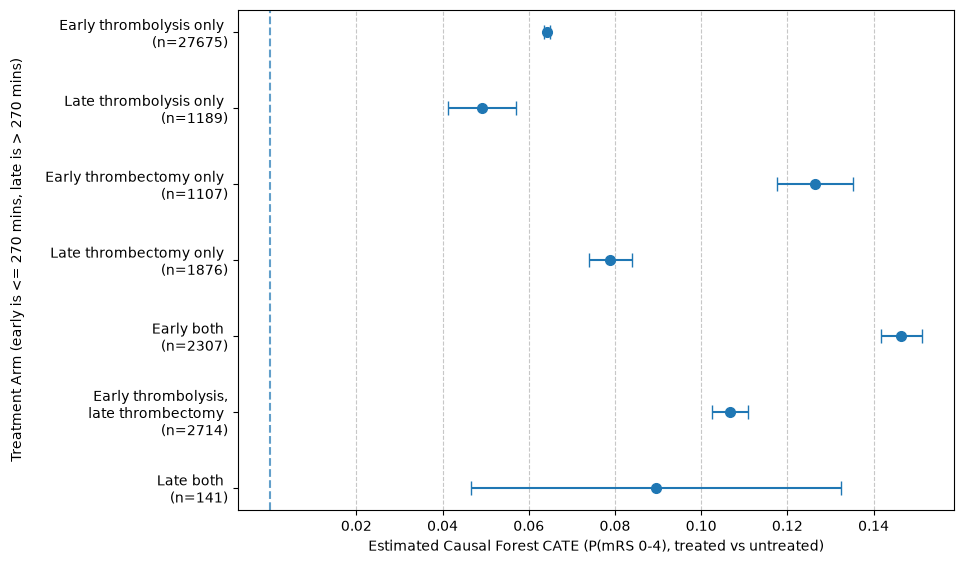

In [19]:
rename_dict = {
    "early_thrombolysis_only": "Early thrombolysis only",
    "late_thrombolysis_only": "Late thrombolysis only",
    "early_thrombectomy_only": "Early thrombectomy only",
    "late_thrombectomy_only": "Late thrombectomy only",
    "early_both": "Early both",
    "early_thrombolysis_late_thrombectomy": "Early thrombolysis,\nlate thrombectomy",
    "late_both": "Late both"
}
# Add n values to the y tick labels
n_values = cate_summary["count"].astype(int).to_dict()
rename_dict = {k: f"{v} \n(n={n_values.get(k, 0)})" for k, v in rename_dict.items()}

fig, ax = plt.subplots(figsize=(10, 6))
# Plot the mean CATE with error bars for 95% CI
ax.errorbar(
    y=range(len(cate_summary.index) - 1, -1, -1),
    x=cate_summary["mean"],
    xerr=[
        cate_summary["mean"] - cate_summary["95% CI lower"],
        cate_summary["95% CI upper"] - cate_summary["mean"],
    ],
    fmt="o",
    markersize=7,  # increase point size
    capsize=5,
    label="Estimated CATE with 95% CI",
)
# Set x ticks at 0.02 intervals
xmin, xmax = ax.get_xlim()
ax.set_xticks(np.arange(np.floor(xmin / 0.02) * 0.02, np.ceil(xmax / 0.02) * 0.02 + 0.02, 0.02))
# Add y tick labels for treatment arms
ax.set_yticks(range(len(cate_summary.index) - 1, -1, -1))
# For y tick labels replace _ with space
ax.set_yticklabels([rename_dict.get(label, label.replace('_', ' ')) for label in cate_summary.index])
# Label the axes
ax.set_xlabel(f"Estimated Causal Forest CATE (P(mRS 0-{MRS_TARGET}), treated vs untreated)")
ax.set_ylabel(f"Treatment Arm (early is <= {CUTOFF} mins, late is > {CUTOFF} mins)", labelpad=15)
# Add grid lines
ax.grid(axis="x", linestyle="--", alpha=0.7)
# Add a horizontal line at y=0
ax.axvline(x=0, linestyle="--", alpha=0.7)
plt.tight_layout(pad=2)
plt.savefig(f"./output/causal_forest_counterfactual_cate_estimates_{MRS_TARGET}.png", dpi=300)
plt.show()